In [1]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

MODEL_TAG = "Hurdle_AR1_GRW_PG_ZR_PAD_SE"
MODEL_NAME = "hurdle_ar1_pg_zr_pad_se"

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_Hurdle" / f"figures_{MODEL_TAG}"
RESULTS = PROJ_ROOT / "results" / "results_Hurdle" / f"results_{MODEL_TAG}"
TRAJECTORIES = PROJ_ROOT / "data" / "trajectory_correlation_data"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
TRAJECTORIES.mkdir(parents=True, exist_ok=True)


In [2]:
# Cell 1B: analysis settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

MIN_PROB = 1e-6
MAX_PROB = 1 - 1e-6
MIN_POS_Q = 1e-12

SCHOLAR_EFFECT_DRAW_MODE = "normal"  # "normal" or "empirical"
POSITIVE_AR1_EFFECT_SCALE = 0.20
HURDLE_EFFECT_SCALE = 0.75
INIT_ACTIVE_EFFECT_SCALE = 1.0
INIT_MAGNITUDE_EFFECT_SCALE = 0.45
RESTART_MAGNITUDE_EFFECT_SCALE = 0.40

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]


In [3]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [4]:
# Cell 2: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["is_active"] = (working_df["pubs_adj"] > 0).astype(int)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["is_active_next"] = working_df.groupby("dblp_id")["is_active"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["pubs_adj", "pubs_adj_next", "is_active", "is_active_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["pubs_adj", "pubs_adj_next", "log_pubs_adj", "log_pubs_next", "log_delta"]].describe())


Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

           pubs_adj  pubs_adj_next  log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000   34701.000000  34701.000000
mean       6.426378       6.446431      1.442084       1.448262      0.006178
std        6.475154       6.499782      1.131298       1.123265      1.057639
min        0.000000       0.000000     -0.713350      -0.713350     -5.028100
25%        2.031715       2.031715      0.924939       0.924939     -0.509761
50%        4.775004       4.775004      1.661082       1.661082     -0.026502
75%        9.012406       9.012406      2.251545       2.251545      0.523108
max       80.686837      80.686837      4.396630       4.396630      4.138016


In [5]:
# Cell 3: career stages

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

working_df["career_stage"] = working_df["CareerAge"].apply(assign_career_stage)
working_df_fit["career_stage"] = working_df_fit["CareerAge"].apply(assign_career_stage)

print("Prod obs by stage:")
print(working_df["career_stage"].value_counts().reindex(stage_order))
print()
print("Trans obs by starting-year stage:")
print(working_df_fit["career_stage"].value_counts().reindex(stage_order))


Prod obs by stage:
career_stage
0-4      10961
5-7       6647
8-13     11114
14-20     8404
Name: count, dtype: int64

Trans obs by starting-year stage:
career_stage
0-4      10918
5-7       6401
8-13     10496
14-20     6886
Name: count, dtype: int64


In [6]:
# Cell 4: build states, zero/active runs, and transition data

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

state_labels = {
    0: "No pubs",
    1: "Some pubs",
}

state_order = [0, 1]
n_states = len(state_order)

df = working_df[working_df[age_col].between(0, Y)].copy()
df = df.sort_values([id_col, age_col]).copy()
df["state"] = (df[prod_col] > 0).astype(int)


def compute_zero_run_length(state_series):
    arr = state_series.to_numpy(dtype=int)
    out = np.zeros(len(arr), dtype=int)
    run = 0
    for i, s in enumerate(arr):
        if s == 0:
            run += 1
            out[i] = run
        else:
            run = 0
            out[i] = 0
    return pd.Series(out, index=state_series.index)


def compute_active_run_length(state_series):
    arr = state_series.to_numpy(dtype=int)
    out = np.zeros(len(arr), dtype=int)
    run = 0
    for i, s in enumerate(arr):
        if s == 1:
            run += 1
            out[i] = run
        else:
            run = 0
            out[i] = 0
    return pd.Series(out, index=state_series.index)


df["zero_run_length"] = (
    df.groupby(id_col, sort=False)["state"]
      .transform(compute_zero_run_length)
      .astype(int)
)

df["active_run_length"] = (
    df.groupby(id_col, sort=False)["state"]
      .transform(compute_active_run_length)
      .astype(int)
)

trans = working_df_fit.copy()
trans["state"] = trans["is_active"].astype(int)
trans["next_state"] = trans["is_active_next"].astype(int)
trans = trans.merge(
    df[[id_col, age_col, "zero_run_length", "active_run_length"]],
    on=[id_col, age_col],
    how="left"
)
trans["zero_run_length"] = trans["zero_run_length"].fillna(0).astype(int)
trans["active_run_length"] = trans["active_run_length"].fillna(0).astype(int)

print(df[[id_col, age_col, prod_col, "state", "zero_run_length", "active_run_length"]].head())
print()
print("State counts:")
print(df["state"].map(state_labels).value_counts())
print()
print("Transition counts by type:")
print(pd.crosstab(trans["state"], trans["next_state"]).rename(index=state_labels, columns=state_labels))
print()
print("Zero-run length summary among zero states:")
print(df.loc[df["state"] == 0, "zero_run_length"].describe())
print()
print("Active-run length summary among active states:")
print(df.loc[df["state"] == 1, "active_run_length"].describe())


                        dblp_id  CareerAge   pubs_adj  state  zero_run_length  \
3  =Ccedil=etintemel:Ugur2001.0          0   5.209137      1                0   
4  =Ccedil=etintemel:Ugur2001.0          1   6.691238      1                0   
5  =Ccedil=etintemel:Ugur2001.0          2  12.901876      1                0   
6  =Ccedil=etintemel:Ugur2001.0          3   4.667694      1                0   
7  =Ccedil=etintemel:Ugur2001.0          4  12.016541      1                0   

   active_run_length  
3                  1  
4                  2  
5                  3  
6                  4  
7                  5  

State counts:
state
Some pubs    31549
No pubs       5577
Name: count, dtype: int64

Transition counts by type:
next_state  No pubs  Some pubs
state                         
No pubs        2318       3061
Some pubs      2823      26499

Zero-run length summary among zero states:
count    5577.00000
mean        2.10615
std         2.02394
min         1.00000
25%         1.

In [7]:
# Cell 5A: yearwise binary transition matrices

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

year_counts = {}
year_P = {}

year_transition_rows = []

for year in range(Y):
    g = trans[trans[age_col] == year]
    counts, probs = transition_counts_and_probs(g)

    probs = probs.combine_first(global_P)

    year_counts[year] = counts
    year_P[year] = probs

    year_transition_rows.append({
        "year": year,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

year_transition_summary = pd.DataFrame(year_transition_rows)

print("Global transition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))
print()
print("Yearwise transition summary:")
display(year_transition_summary.round(3))


Global transition probabilities:
next_state  No pubs  Some pubs
state                         
No pubs       0.431      0.569
Some pubs     0.096      0.904

Yearwise transition summary:


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


In [8]:
# Cell 5B: stagewise binary transition summary

stage_counts = {}
stage_P = {}
stage_transition_rows = []

for stage in stage_order:
    g = trans[trans["career_stage"] == stage]
    counts, probs = transition_counts_and_probs(g)
    probs = probs.combine_first(global_P)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    stage_transition_rows.append({
        "stage": stage,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

stage_transition_summary = pd.DataFrame(stage_transition_rows)

display(stage_transition_summary.round(3))


,stage,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0-4,10918,0.365,0.635,0.099,0.901
1,5-7,6401,0.419,0.581,0.083,0.917
2,8-13,10496,0.463,0.537,0.094,0.906
3,14-20,6886,0.485,0.515,0.109,0.891


Latent scholar-effect distribution, estimated from centered positive log productivity


,n_scholars_with_positive_years,sigma_within2_centered_log_q,raw_var_scholar_mean_centered_log_q,mean_noise_var,tau_scholar2_mom,tau_scholar_mom,sd_shrunk_scholar_effect,mean_shrinkage,median_shrinkage
0,2425,0.313891,0.35159,0.035178,0.316412,0.562505,0.523504,0.908355,0.9291


Scholar-effect quantiles


,u_hat
0.01,-0.983711
0.05,-0.788867
0.25,-0.389268
0.50,-0.027289
0.75,0.347734
0.95,0.932052
0.99,1.379551


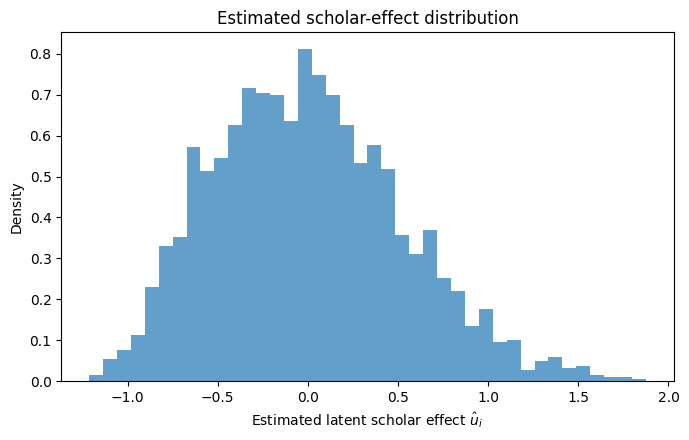

Initial activity model with scholar effect
Converged: True
NLL: 1027.263
intercept: 1.3663
scholar coef: 0.9135

logistic dropout model: productivity + active duration + scholar effect
Converged: True
Negative log-likelihood: 7810.995
Fitted gamma on log(1 + Q_t): 0.4315
Fitted active-duration delta on log(1 + active-run excess): -0.9311
Fitted scholar-effect coefficient per tau: -0.4727
Interpretation of delta sign: longer active spells decrease dropout hazard
Interpretation of scholar-effect sign: higher u lowers dropout hazard



,year,n_active_transitions,observed_dropout_rate,dropout_intercept,dropout_gamma_log1p_q,dropout_delta_log1p_active_run_excess,dropout_scholar_coef_per_tau,active_duration_effect_direction,scholar_effect_direction,pred_drop_q50_run1_u_low,pred_drop_q50_run1_u_mid,pred_drop_q50_run1_u_high,pred_drop_q25_run1,pred_drop_q50_run1,pred_drop_q75_run1,pred_drop_q95_run1,pred_drop_q50_run2,pred_drop_q50_run5,pred_drop_q50_run10
0,0,1633,0.1641,-0.9454,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.2139,0.1450,0.0956,0.1726,0.1450,0.1212,0.0951,0.0817,0.0365,0.0195
1,1,1710,0.1088,-0.9608,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.2113,0.1431,0.0943,0.1704,0.1431,0.1195,0.0938,0.0805,0.0360,0.0192
2,2,1879,0.0750,-1.1385,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.1832,0.1227,0.0802,0.1467,0.1227,0.1021,0.0797,0.0683,0.0303,0.0161
3,3,1989,0.0825,-0.8144,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.2367,0.1620,0.1075,0.1921,0.1620,0.1358,0.1070,0.0921,0.0414,0.0222
4,4,1997,0.0756,-0.7097,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.2562,0.1767,0.1180,0.2088,0.1767,0.1486,0.1174,0.1012,0.0458,0.0245
5,5,1942,0.0772,-0.5329,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.2913,0.2039,0.1377,0.2395,0.2039,0.1723,0.1370,0.1184,0.0541,0.0291
6,6,1880,0.0782,-0.4390,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.3110,0.2196,0.1492,0.2571,0.2196,0.1862,0.1485,0.1286,0.0592,0.0319
7,7,1806,0.0952,-0.1796,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.3692,0.2673,0.1852,0.3096,0.2673,0.2287,0.1844,0.1606,0.0754,0.0410
8,8,1710,0.0860,-0.2961,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.3425,0.2451,0.1683,0.2853,0.2451,0.2088,0.1675,0.1455,0.0676,0.0367
9,9,1636,0.0935,-0.1853,0.4315,-0.9311,-0.4727,lower dropout,lower dropout,0.3678,0.2661,0.1844,0.3084,0.2661,0.2277,0.1835,0.1598,0.0750,0.0408



Zero-run-duration + scholar-effect restart model
Converged: True
Negative log-likelihood: 3461.257
Fitted rho on zero-run excess: 0.2909
Fitted scholar-effect coefficient per tau: 0.2372
Interpretation of scholar-effect sign: higher u raises restart probability



,year,n_zero_transitions,observed_restart_rate,restart_intercept,restart_rho_zero_run_excess,restart_scholar_coef_per_tau,scholar_effect_direction,pred_restart_run1_u_low,pred_restart_run1_u_mid,pred_restart_run1_u_high,pred_restart_run1,pred_restart_run2,pred_restart_run3,pred_restart_run5
0,0,434,0.6198,0.5606,0.2909,0.2372,higher restart,0.5801,0.6366,0.6895,0.6366,0.5670,0.4947,0.3537
1,1,433,0.6836,0.9685,0.2909,0.2372,higher restart,0.6751,0.7248,0.7695,0.7248,0.6632,0.5955,0.4514
2,2,323,0.6378,0.8736,0.2909,0.2372,higher restart,0.6539,0.7055,0.7523,0.7055,0.6417,0.5724,0.4280
3,3,258,0.6202,0.8683,0.2909,0.2372,higher restart,0.6527,0.7044,0.7513,0.7044,0.6405,0.5712,0.4268
4,4,262,0.5916,0.7349,0.2909,0.2372,higher restart,0.6219,0.6759,0.7255,0.6759,0.6092,0.5382,0.3945
5,5,258,0.5581,0.6283,0.2909,0.2372,higher restart,0.5965,0.6521,0.7038,0.6521,0.5836,0.5116,0.3693
6,6,262,0.5916,0.8075,0.2909,0.2372,higher restart,0.6388,0.6916,0.7398,0.6916,0.6264,0.5562,0.4119
7,7,253,0.5929,0.8283,0.2909,0.2372,higher restart,0.6436,0.6960,0.7437,0.6960,0.6312,0.5613,0.4170
8,8,275,0.5927,0.8053,0.2909,0.2372,higher restart,0.6383,0.6911,0.7393,0.6911,0.6258,0.5557,0.4114
9,9,259,0.5174,0.4961,0.2909,0.2372,higher restart,0.5644,0.6215,0.6755,0.6215,0.5511,0.4786,0.3391


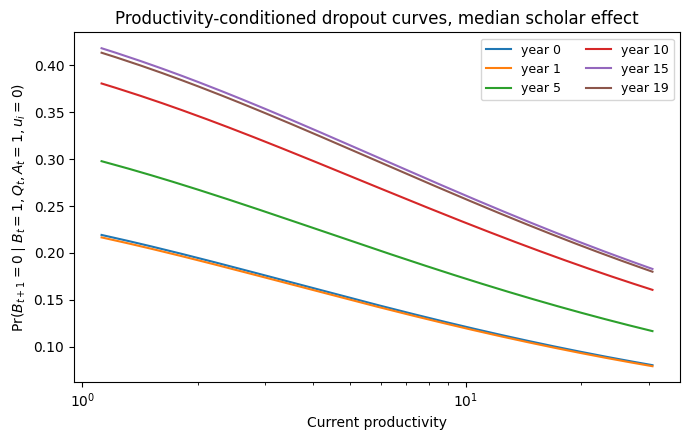

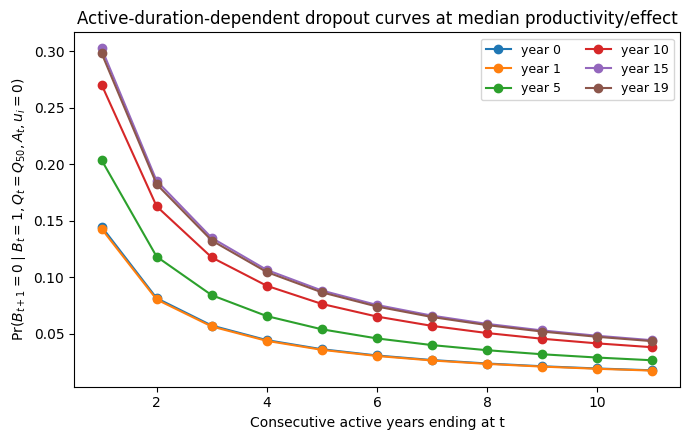

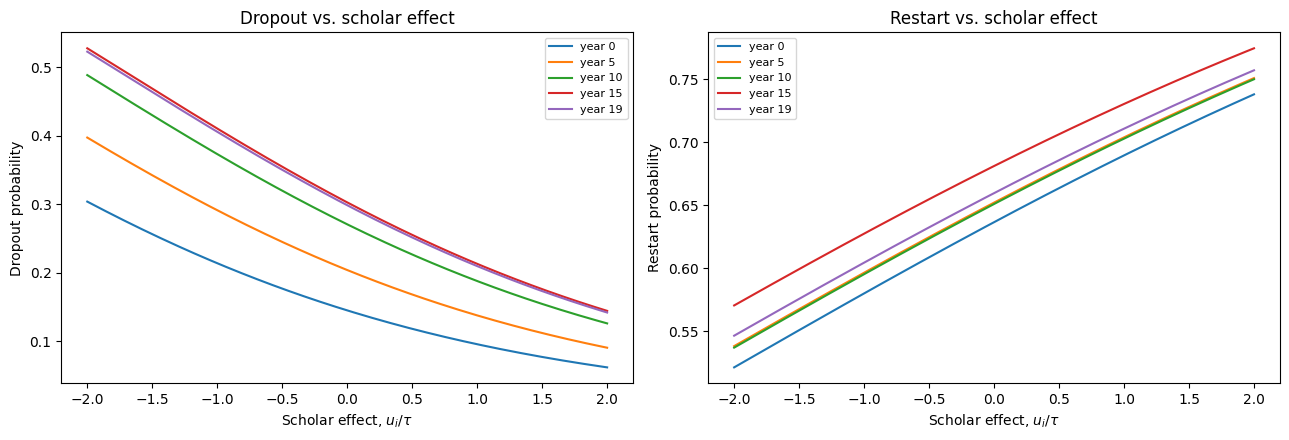

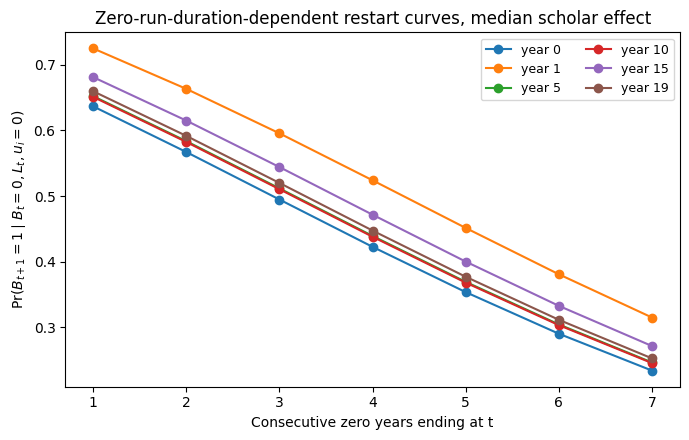

In [9]:
# Cell 6A: fit scholar effects, param dropout, and zero-duration restart


scholar_effect_source = df.loc[
    (df["state"] == 1) &
    (df[prod_col] > 0) &
    df[age_col].between(0, Y),
    [id_col, age_col, prod_col]
].copy()

scholar_effect_source["log_q_pos"] = np.log(scholar_effect_source[prod_col])
year_log_means = scholar_effect_source.groupby(age_col)["log_q_pos"].mean()
scholar_effect_source["year_mean_log_q"] = scholar_effect_source[age_col].map(year_log_means)
scholar_effect_source["centered_log_q"] = (
    scholar_effect_source["log_q_pos"] - scholar_effect_source["year_mean_log_q"]
)

scholar_effect_raw = (
    scholar_effect_source
    .groupby(id_col)
    .agg(
        n_pos_years=("centered_log_q", "size"),
        mean_centered_log_q=("centered_log_q", "mean"),
        sd_centered_log_q=("centered_log_q", "std"),
    )
    .reset_index()
)

se_with_means = scholar_effect_source.merge(
    scholar_effect_raw[[id_col, "mean_centered_log_q"]],
    on=id_col,
    how="left"
)
within_resid = se_with_means["centered_log_q"] - se_with_means["mean_centered_log_q"]
sigma_within2 = float(np.nanmean(within_resid.to_numpy(dtype=float) ** 2))
raw_mean_var = float(scholar_effect_raw["mean_centered_log_q"].var(ddof=0))
mean_noise_var = float(np.mean(sigma_within2 / scholar_effect_raw["n_pos_years"].clip(lower=1)))
tau_scholar2 = max(raw_mean_var - mean_noise_var, 1e-8)
tau_scholar = float(np.sqrt(tau_scholar2))

scholar_effect_raw["shrinkage"] = (
    tau_scholar2 /
    (tau_scholar2 + sigma_within2 / scholar_effect_raw["n_pos_years"].clip(lower=1))
)
scholar_effect_raw["scholar_effect"] = (
    scholar_effect_raw["shrinkage"] * scholar_effect_raw["mean_centered_log_q"]
)

scholar_effect_raw["scholar_effect"] = (
    scholar_effect_raw["scholar_effect"] - scholar_effect_raw["scholar_effect"].mean()
)

scholar_effect_sd_empirical = float(scholar_effect_raw["scholar_effect"].std(ddof=0))
if not np.isfinite(scholar_effect_sd_empirical) or scholar_effect_sd_empirical <= 0:
    scholar_effect_sd_empirical = tau_scholar

scholar_effect_df = scholar_effect_raw[[
    id_col,
    "n_pos_years",
    "mean_centered_log_q",
    "shrinkage",
    "scholar_effect",
]].copy()

scholar_effect_summary = pd.DataFrame([{
    "n_scholars_with_positive_years": len(scholar_effect_df),
    "sigma_within2_centered_log_q": sigma_within2,
    "raw_var_scholar_mean_centered_log_q": raw_mean_var,
    "mean_noise_var": mean_noise_var,
    "tau_scholar2_mom": tau_scholar2,
    "tau_scholar_mom": tau_scholar,
    "sd_shrunk_scholar_effect": scholar_effect_sd_empirical,
    "mean_shrinkage": scholar_effect_df["shrinkage"].mean(),
    "median_shrinkage": scholar_effect_df["shrinkage"].median(),
}])

trans = trans.drop(columns=["scholar_effect"], errors="ignore")
df = df.drop(columns=["scholar_effect"], errors="ignore")

trans = trans.merge(scholar_effect_df[[id_col, "scholar_effect"]], on=id_col, how="left")
trans["scholar_effect"] = trans["scholar_effect"].fillna(0.0)
df = df.merge(scholar_effect_df[[id_col, "scholar_effect"]], on=id_col, how="left")
df["scholar_effect"] = df["scholar_effect"].fillna(0.0)

print("Latent scholar-effect distribution, estimated from centered positive log productivity")
display(scholar_effect_summary)
print("Scholar-effect quantiles")
display(scholar_effect_df["scholar_effect"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("u_hat"))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(scholar_effect_df["scholar_effect"], bins=40, density=True, alpha=0.70)
ax.set_xlabel(r"Estimated latent scholar effect $\hat u_i$")
ax.set_ylabel("Density")
ax.set_title("Estimated scholar-effect distribution")
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_scholarEffectDistribution.png", dpi=300, bbox_inches="tight")
plt.show()


def sigmoid_stable(x):
    x = np.clip(np.asarray(x, dtype=float), -35, 35)
    return 1 / (1 + np.exp(-x))


def logit_clipped(p):
    p = np.clip(p, MIN_PROB, MAX_PROB)
    return np.log(p / (1 - p))

init_active_fit = df.loc[df[age_col] == 0, [id_col, "state", "scholar_effect"]].copy()
init_y = init_active_fit["state"].astype(float).to_numpy()
init_u = init_active_fit["scholar_effect"].astype(float).to_numpy()
init_rate = init_y.mean()


def init_active_nll(theta):
    intercept, scholar_coef = theta
    eta = intercept + scholar_coef * init_u
    p = sigmoid_stable(eta)
    return -np.sum(
        init_y * np.log(np.clip(p, MIN_PROB, MAX_PROB)) +
        (1 - init_y) * np.log(np.clip(1 - p, MIN_PROB, MAX_PROB))
    )

init_active_opt = minimize(
    init_active_nll,
    x0=np.array([logit_clipped(init_rate), 0.0]),
    method="L-BFGS-B",
    bounds=[(-10, 10), (-10, 10)],
)

if not init_active_opt.success:
    print("warning: initial activity model did not converge")
    print(init_active_opt.message)

fitted_init_active_intercept = float(init_active_opt.x[0])
fitted_init_active_scholar_coef = float(init_active_opt.x[1])


def predict_init_active_prob(scholar_effect=0.0):
    u_arr = np.asarray(scholar_effect, dtype=float)
    eta = fitted_init_active_intercept + fitted_init_active_scholar_coef * u_arr
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

active_dropout_fit = trans.loc[
    (trans["state"] == 1) &
    trans["pubs_adj"].notna() &
    trans["next_state"].notna() &
    trans["active_run_length"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    [id_col, "CareerAge", "pubs_adj", "next_state", "active_run_length", "scholar_effect"]
].copy()

active_dropout_fit["drops_to_zero"] = (active_dropout_fit["next_state"] == 0).astype(int)
active_dropout_fit["log1p_q"] = np.log1p(active_dropout_fit["pubs_adj"].clip(lower=0))
active_dropout_fit["active_run_length"] = active_dropout_fit["active_run_length"].clip(lower=1).astype(int)
active_dropout_fit["active_run_excess"] = active_dropout_fit["active_run_length"] - 1
active_dropout_fit["log1p_active_run_excess"] = np.log1p(active_dropout_fit["active_run_excess"])

active_dropout_fit["scholar_effect_scaled"] = active_dropout_fit["scholar_effect"] / max(tau_scholar, 1e-8)

year_idx = active_dropout_fit["CareerAge"].astype(int).to_numpy()
x_log1p_q = active_dropout_fit["log1p_q"].to_numpy(dtype=float)
x_log1p_active_run_excess = active_dropout_fit["log1p_active_run_excess"].to_numpy(dtype=float)
x_scholar_effect_scaled = active_dropout_fit["scholar_effect_scaled"].to_numpy(dtype=float)
y_drop = active_dropout_fit["drops_to_zero"].to_numpy(dtype=float)

initial_intercepts = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    raw_rate = g["drops_to_zero"].mean() if len(g) > 0 else y_drop.mean()
    initial_intercepts.append(logit_clipped(raw_rate))

initial_intercepts = np.asarray(initial_intercepts, dtype=float)
initial_log_gamma = np.log(0.25)
initial_active_duration_delta = 0.0
initial_dropout_scholar_coef = 0.0
initial_theta = np.r_[
    initial_intercepts,
    initial_log_gamma,
    initial_active_duration_delta,
    initial_dropout_scholar_coef,
]


def dropout_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    gamma = np.exp(theta[Y])
    active_duration_delta = theta[Y + 1]
    scholar_coef = theta[Y + 2]

    eta = (
        intercepts[year_idx]
        - gamma * x_log1p_q
        + active_duration_delta * x_log1p_active_run_excess
        + scholar_coef * x_scholar_effect_scaled
    )
    p_drop = sigmoid_stable(eta)

    nll = -np.sum(
        y_drop * np.log(np.clip(p_drop, MIN_PROB, MAX_PROB)) +
        (1 - y_drop) * np.log(np.clip(1 - p_drop, MIN_PROB, MAX_PROB))
    )
    return nll

bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0)), (-10, 10), (-10, 10)]
opt = minimize(
    dropout_neg_log_likelihood,
    initial_theta,
    method="L-BFGS-B",
    bounds=bounds,
)

if not opt.success:
    print("warning: dropout model did not converge")
    print(opt.message)

fitted_intercepts = opt.x[:Y]
fitted_gamma = float(np.exp(opt.x[Y]))
fitted_active_duration_delta = float(opt.x[Y + 1])
fitted_dropout_scholar_coef = float(opt.x[Y + 2])


def predict_dropout_prob(q, year, active_run_length=1, scholar_effect=0.0):
    q_arr, year_arr, active_arr, u_arr = np.broadcast_arrays(
        np.asarray(q, dtype=float),
        np.asarray(year, dtype=int),
        np.asarray(active_run_length, dtype=float),
        np.asarray(scholar_effect, dtype=float),
    )
    active_run_excess = np.clip(active_arr - 1, 0, None)
    u_scaled = u_arr / max(tau_scholar, 1e-8)
    eta = (
        fitted_intercepts[year_arr]
        - fitted_gamma * np.log1p(np.clip(q_arr, 0, None))
        + fitted_active_duration_delta * np.log1p(active_run_excess)
        + fitted_dropout_scholar_coef * u_scaled
    )
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

q_ref = active_dropout_fit["pubs_adj"].quantile([0.25, 0.50, 0.75, 0.95]).to_dict()
active_run_ref = active_dropout_fit["active_run_length"].quantile([0.25, 0.50, 0.75, 0.95]).to_dict()
active_run_ref = {k: max(1, int(round(v))) for k, v in active_run_ref.items()}
u_low, u_mid, u_high = -tau_scholar, 0.0, tau_scholar

dropout_param_rows = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    observed_dropout_rate = g["drops_to_zero"].mean() if len(g) > 0 else np.nan
    dropout_param_rows.append({
        "year": year,
        "n_active_transitions": len(g),
        "observed_dropout_rate": observed_dropout_rate,
        "dropout_intercept": fitted_intercepts[year],
        "dropout_gamma_log1p_q": fitted_gamma,
        "dropout_delta_log1p_active_run_excess": fitted_active_duration_delta,
        "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
        "active_duration_effect_direction": "higher dropout" if fitted_active_duration_delta > 0 else "lower dropout",
        "scholar_effect_direction": "higher dropout" if fitted_dropout_scholar_coef > 0 else "lower dropout",
        "pred_drop_q50_run1_u_low": predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=u_low),
        "pred_drop_q50_run1_u_mid": predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=u_mid),
        "pred_drop_q50_run1_u_high": predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=u_high),
        "pred_drop_q25_run1": predict_dropout_prob(q_ref[0.25], year, active_run_length=1),
        "pred_drop_q50_run1": predict_dropout_prob(q_ref[0.50], year, active_run_length=1),
        "pred_drop_q75_run1": predict_dropout_prob(q_ref[0.75], year, active_run_length=1),
        "pred_drop_q95_run1": predict_dropout_prob(q_ref[0.95], year, active_run_length=1),
        "pred_drop_q50_run2": predict_dropout_prob(q_ref[0.50], year, active_run_length=2),
        "pred_drop_q50_run5": predict_dropout_prob(q_ref[0.50], year, active_run_length=5),
        "pred_drop_q50_run10": predict_dropout_prob(q_ref[0.50], year, active_run_length=10),
    })

dropout_param_summary = pd.DataFrame(dropout_param_rows)

restart_fit = trans.loc[
    (trans["state"] == 0) &
    trans["next_state"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    [id_col, "CareerAge", "next_state", "zero_run_length", "scholar_effect"]
].copy()

restart_fit["restarts"] = (restart_fit["next_state"] == 1).astype(int)
restart_fit["zero_run_length"] = restart_fit["zero_run_length"].clip(lower=1).astype(int)
restart_fit["zero_run_excess"] = restart_fit["zero_run_length"] - 1
restart_fit["scholar_effect_scaled"] = restart_fit["scholar_effect"] / max(tau_scholar, 1e-8)

restart_year_idx = restart_fit["CareerAge"].astype(int).to_numpy()
x_zero_run_excess = restart_fit["zero_run_excess"].to_numpy(dtype=float)
x_restart_scholar_effect_scaled = restart_fit["scholar_effect_scaled"].to_numpy(dtype=float)
y_restart = restart_fit["restarts"].to_numpy(dtype=float)

restart_initial_intercepts = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    raw_rate = g["restarts"].mean() if len(g) > 0 else y_restart.mean()
    restart_initial_intercepts.append(logit_clipped(raw_rate))

restart_initial_intercepts = np.asarray(restart_initial_intercepts, dtype=float)
restart_initial_log_rho = np.log(0.25)
restart_initial_scholar_coef = 0.0
restart_initial_theta = np.r_[restart_initial_intercepts, restart_initial_log_rho, restart_initial_scholar_coef]


def restart_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    rho = np.exp(theta[Y])
    scholar_coef = theta[Y + 1]

    eta = (
        intercepts[restart_year_idx]
        - rho * x_zero_run_excess
        + scholar_coef * x_restart_scholar_effect_scaled
    )
    p_restart = sigmoid_stable(eta)

    nll = -np.sum(
        y_restart * np.log(np.clip(p_restart, MIN_PROB, MAX_PROB)) +
        (1 - y_restart) * np.log(np.clip(1 - p_restart, MIN_PROB, MAX_PROB))
    )
    return nll

restart_bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0)), (-10, 10)]
restart_opt = minimize(
    restart_neg_log_likelihood,
    restart_initial_theta,
    method="L-BFGS-B",
    bounds=restart_bounds,
)

if not restart_opt.success:
    print("warning: restart model did not converge")
    print(restart_opt.message)

fitted_restart_intercepts = restart_opt.x[:Y]
fitted_restart_rho = float(np.exp(restart_opt.x[Y]))
fitted_restart_scholar_coef = float(restart_opt.x[Y + 1])


def predict_restart_prob(zero_run_length, year, scholar_effect=0.0):
    zero_run_length_arr, year_arr, u_arr = np.broadcast_arrays(
        np.asarray(zero_run_length, dtype=float),
        np.asarray(year, dtype=int),
        np.asarray(scholar_effect, dtype=float),
    )
    zero_run_excess = np.clip(zero_run_length_arr - 1, 0, None)
    u_scaled = u_arr / max(tau_scholar, 1e-8)
    eta = (
        fitted_restart_intercepts[year_arr]
        - fitted_restart_rho * zero_run_excess
        + fitted_restart_scholar_coef * u_scaled
    )
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

restart_param_rows = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    observed_restart_rate = g["restarts"].mean() if len(g) > 0 else np.nan
    restart_param_rows.append({
        "year": year,
        "n_zero_transitions": len(g),
        "observed_restart_rate": observed_restart_rate,
        "restart_intercept": fitted_restart_intercepts[year],
        "restart_rho_zero_run_excess": fitted_restart_rho,
        "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
        "scholar_effect_direction": "higher restart" if fitted_restart_scholar_coef > 0 else "lower restart",
        "pred_restart_run1_u_low": predict_restart_prob(1, year, scholar_effect=u_low),
        "pred_restart_run1_u_mid": predict_restart_prob(1, year, scholar_effect=u_mid),
        "pred_restart_run1_u_high": predict_restart_prob(1, year, scholar_effect=u_high),
        "pred_restart_run1": predict_restart_prob(1, year),
        "pred_restart_run2": predict_restart_prob(2, year),
        "pred_restart_run3": predict_restart_prob(3, year),
        "pred_restart_run5": predict_restart_prob(5, year),
    })

restart_param_summary = pd.DataFrame(restart_param_rows)

print("Initial activity model with scholar effect")
print(f"Converged: {init_active_opt.success}")
print(f"NLL: {init_active_opt.fun:.3f}")
print(f"intercept: {fitted_init_active_intercept:.4f}")
print(f"scholar coef: {fitted_init_active_scholar_coef:.4f}")
print()
print("logistic dropout model: productivity + active duration + scholar effect")
print(f"Converged: {opt.success}")
print(f"Negative log-likelihood: {opt.fun:.3f}")
print(f"Fitted gamma on log(1 + Q_t): {fitted_gamma:.4f}")
print(f"Fitted active-duration delta on log(1 + active-run excess): {fitted_active_duration_delta:.4f}")
print(f"Fitted scholar-effect coefficient per tau: {fitted_dropout_scholar_coef:.4f}")
print("Interpretation of delta sign:", "longer active spells increase dropout hazard" if fitted_active_duration_delta > 0 else "longer active spells decrease dropout hazard")
print("Interpretation of scholar-effect sign:", "higher u raises dropout hazard" if fitted_dropout_scholar_coef > 0 else "higher u lowers dropout hazard")
print()
display(dropout_param_summary.round(4))
print()
print("Zero-run-duration + scholar-effect restart model")
print(f"Converged: {restart_opt.success}")
print(f"Negative log-likelihood: {restart_opt.fun:.3f}")
print(f"Fitted rho on zero-run excess: {fitted_restart_rho:.4f}")
print(f"Fitted scholar-effect coefficient per tau: {fitted_restart_scholar_coef:.4f}")
print("Interpretation of scholar-effect sign:", "higher u raises restart probability" if fitted_restart_scholar_coef > 0 else "higher u lowers restart probability")
print()
display(restart_param_summary.round(4))

q_grid = np.linspace(
    active_dropout_fit["pubs_adj"].quantile(0.01),
    active_dropout_fit["pubs_adj"].quantile(0.99),
    300,
)
q_grid = np.clip(q_grid, MIN_POS_Q, None)

fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(
        q_grid,
        predict_dropout_prob(q_grid, year, active_run_length=1, scholar_effect=0.0),
        label=f"year {year}")

ax.set_xscale("log")
ax.set_xlabel("Current productivity")
ax.set_ylabel(r"Pr($B_{t+1}=0 \mid B_t=1, Q_t, A_t=1, u_i=0$)")
ax.set_title("Productivity-conditioned dropout curves, median scholar effect")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_paramDropoutCurves.png", dpi=300, bbox_inches="tight")
plt.show()

active_run_grid = np.arange(1, 12)
q_for_duration_curve = q_ref[0.50]
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(
        active_run_grid,
        predict_dropout_prob(q_for_duration_curve, year, active_run_length=active_run_grid, scholar_effect=0.0),
        marker="o",
        label=f"year {year}")

ax.set_xlabel("Consecutive active years ending at t")
ax.set_ylabel(r"Pr($B_{t+1}=0 \mid B_t=1, Q_t=Q_{50}, A_t, u_i=0$)")
ax.set_title("Active-duration-dependent dropout curves at median productivity/effect")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_activeDurationDropoutCurves.png", dpi=300, bbox_inches="tight")
plt.show()

u_grid = np.linspace(-2 * tau_scholar, 2 * tau_scholar, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for year in [0, 5, 10, 15, 19]:
    axes[0].plot(
        u_grid / max(tau_scholar, 1e-8),
        predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=u_grid),
        label=f"year {year}")
    axes[1].plot(
        u_grid / max(tau_scholar, 1e-8),
        predict_restart_prob(1, year, scholar_effect=u_grid),
        label=f"year {year}")
axes[0].set_xlabel(r"Scholar effect, $u_i / \tau$")
axes[0].set_ylabel("Dropout probability")
axes[0].set_title("Dropout vs. scholar effect")
axes[1].set_xlabel(r"Scholar effect, $u_i / \tau$")
axes[1].set_ylabel("Restart probability")
axes[1].set_title("Restart vs. scholar effect")
for ax in axes:
    ax.legend(ncols=1, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_scholarEffectCurves.png", dpi=300, bbox_inches="tight")
plt.show()

run_grid = np.arange(1, 8)
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(
        run_grid,
        predict_restart_prob(run_grid, year, scholar_effect=0.0),
        marker="o",
        label=f"year {year}")

ax.set_xlabel("Consecutive zero years ending at t")
ax.set_ylabel(r"Pr($B_{t+1}=1 \mid B_t=0, L_t, u_i=0$)")
ax.set_title("Zero-run-duration-dependent restart curves, median scholar effect")
ax.legend(ncols=2, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartDurationCurves.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# Cell 6B: fit positive-only yearwise log AR(1)

positive_ar1_fit = working_df_fit[(working_df_fit["pubs_adj"] > 0) & (working_df_fit["pubs_adj_next"] > 0)].copy()
positive_ar1_fit["log_pubs_pos"] = np.log(positive_ar1_fit["pubs_adj"])
positive_ar1_fit["log_pubs_pos_next"] = np.log(positive_ar1_fit["pubs_adj_next"])

def fit_positive_log_ar1(subset):
    x = subset["log_pubs_pos"].to_numpy()
    y = subset["log_pubs_pos_next"].to_numpy()

    if len(x) < 3:
        return {
            "n": len(x),
            "intercept": np.nan,
            "beta": np.nan,
            "sigma_resid": np.nan,
            "var_resid": np.nan,
            "implied_stationary_mean_log": np.nan,
            "implied_stationary_var_log": np.nan,
            "mean_resid": np.nan,
            "sd_resid": np.nan,}

    X = np.column_stack([np.ones(len(x)), x])

    intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = intercept + beta * x
    resid = y - y_hat

    sigma = np.sqrt(np.mean(resid**2))
    var = sigma**2

    if abs(beta) < 1:
        implied_mean = intercept / (1 - beta)
        implied_var = var / (1 - beta**2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    return {
        "n": len(x),
        "intercept": intercept,
        "beta": beta,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log": implied_mean,
        "implied_stationary_var_log": implied_var,
        "mean_resid": resid.mean(),
        "sd_resid": resid.std(ddof=0),}


global_ar1_params = pd.DataFrame([{"model": "global_positive", **fit_positive_log_ar1(positive_ar1_fit)}])

year_ar1_rows = []

for year in range(Y):
    subset = positive_ar1_fit[positive_ar1_fit["CareerAge"] == year].copy()
    year_ar1_rows.append({"year": year, **fit_positive_log_ar1(subset)})

year_ar1_params = pd.DataFrame(year_ar1_rows)

print("Global positive-only AR(1)")
display(global_ar1_params)

print("Yearwise positive-only AR(1)")
display(year_ar1_params)

print("problematic abs beta >= 1")
display(year_ar1_params.loc[year_ar1_params["beta"].abs() >= 1])


Global positive-only AR(1)


,model,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,global_positive,26499,0.706327,0.597931,0.646869,0.41844,1.75673,0.65129,-2.150478e-16,0.646869


Yearwise positive-only AR(1)


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


problematic abs beta >= 1


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid


In [11]:
# Cell 7A: fit init gamma and restart exponential


q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()
q0_pos_empirical = q0_empirical[q0_empirical > 0]

p_init_active = (q0_empirical > 0).mean()

gamma_q0_shape, gamma_q0_loc, gamma_q0_scale = stats.gamma.fit(q0_pos_empirical, floc=0)
gamma_q0_rate = 1 / gamma_q0_scale
gamma_q0_mean = gamma_q0_shape * gamma_q0_scale

restart_q_empirical = trans.loc[
    (trans["state"] == 0) & (trans["next_state"] == 1),
    "pubs_adj_next"
].dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

alpha_restart = restart_q_empirical.mean()
lambda_restart = 1 / alpha_restart

print("Initial active probability:", p_init_active)
print("Initial positive Gamma shape:", gamma_q0_shape)
print("Initial positive Gamma scale:", gamma_q0_scale)
print("Initial positive Gamma rate:", gamma_q0_rate)
print("Initial positive Gamma implied mean:", gamma_q0_mean)
print()
print("Restart exponential scale alpha:", alpha_restart)
print("Restart exponential rate lambda:", lambda_restart)
print("Empirical restart n:", len(restart_q_empirical))
print()
print("Initial positive productivity empirical summary:")
print(q0_pos_empirical.describe())
print()
print("Restart magnitude empirical summary:")
print(restart_q_empirical.describe())


Initial active probability: 0.7902368293861769
Initial positive Gamma shape: 2.15167023161791
Initial positive Gamma scale: 2.531674038263246
Initial positive Gamma rate: 0.3949955582299252
Initial positive Gamma implied mean: 5.4473276642909285

Restart exponential scale alpha: 4.299784306131943
Restart exponential rate lambda: 0.23256980555371004
Empirical restart n: 3061

Initial positive productivity empirical summary:
count    1635.000000
mean        5.447328
std         4.619311
min         1.231551
25%         2.625676
50%         4.207789
75%         6.945516
max        74.304910
Name: pubs_adj, dtype: float64

Restart magnitude empirical summary:
count    3061.000000
mean        4.299784
std         3.505162
min         1.058909
25%         1.951028
50%         3.225469
75%         5.411175
max        30.222393
Name: pubs_adj_next, dtype: float64


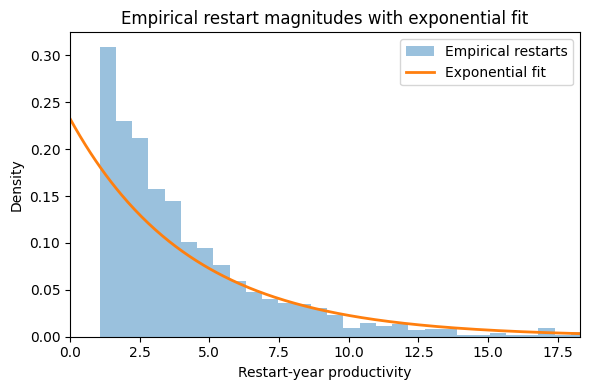

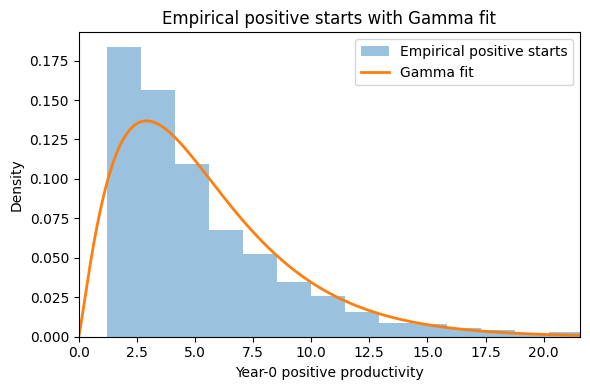

In [12]:
# Cell 7B: restart dx check

x_max = np.quantile(restart_q_empirical, 0.99)
x_grid = np.linspace(0, x_max, 300)
restart_pdf = lambda_restart * np.exp(-lambda_restart * x_grid)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(
    restart_q_empirical,
    bins=50,
    density=True,
    alpha=0.45,
    label="Empirical restarts")

ax.plot(
    x_grid,
    restart_pdf,
    linewidth=2,
    label="Exponential fit")

ax.set_xlim(0, x_max)
ax.set_xlabel("Restart-year productivity")
ax.set_ylabel("Density")
ax.set_title("Empirical restart magnitudes with exponential fit")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFit.png", dpi=300, bbox_inches="tight")
plt.show()

x0_max = np.quantile(q0_pos_empirical, 0.99)
x0_grid = np.linspace(0, x0_max, 300)
q0_gamma_pdf = stats.gamma.pdf(x0_grid, a=gamma_q0_shape, loc=0, scale=gamma_q0_scale)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(
    q0_pos_empirical,
    bins=50,
    density=True,
    alpha=0.45,
    label="Empirical positive starts")
ax.plot(
    x0_grid,
    q0_gamma_pdf,
    linewidth=2,
    label="Gamma fit")
ax.set_xlim(0, x0_max)
ax.set_xlabel("Year-0 positive productivity")
ax.set_ylabel("Density")
ax.set_title("Empirical positive starts with Gamma fit")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_q0GammaFit.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# Cell 8: simulation helpers


def make_ar1_year_lookup(year_ar1_params):
    return (year_ar1_params
        .set_index("year")[["intercept", "beta", "sigma_resid"]].to_dict("index"))

ar1_year_lookup = make_ar1_year_lookup(year_ar1_params)


def draw_exponential_positive(scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.exponential(scale=scale, size=size), MIN_POS_Q, None)


def draw_gamma_positive(shape, scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.gamma(shape=shape, scale=scale, size=size), MIN_POS_Q, None)


def draw_scholar_effects(n, rng, mode=SCHOLAR_EFFECT_DRAW_MODE):
    if mode == "empirical":
        values = scholar_effect_df["scholar_effect"].dropna().to_numpy(dtype=float)
        if len(values) == 0:
            return np.zeros(n, dtype=float)
        return rng.choice(values, size=n, replace=True)
    if mode == "normal":
        return rng.normal(loc=0.0, scale=tau_scholar, size=n)
    raise ValueError("SCHOLAR_EFFECT_DRAW_MODE must be 'normal' or 'empirical'")


def scholar_effect_multiplier(scholar_effect, effect_scale):
    """Positive multiplicative effect with empirical mean correction."""
    u = np.asarray(scholar_effect, dtype=float)
    if effect_scale == 0:
        return np.ones_like(u, dtype=float)
    ref_u = scholar_effect_df["scholar_effect"].dropna().to_numpy(dtype=float)
    if len(ref_u) == 0:
        denom = 1.0
    else:
        denom = float(np.mean(np.exp(effect_scale * ref_u)))
        if not np.isfinite(denom) or denom <= 0:
            denom = 1.0
    return np.exp(effect_scale * u) / denom


def draw_next_binary_state_parametric(
    q_current,
    b_current,
    zero_run_length_current,
    active_run_length_current,
    scholar_effect_current,
    year,
    rng):

    q_current = np.asarray(q_current, dtype=float)
    b_current = np.asarray(b_current, dtype=int)
    zero_run_length_current = np.asarray(zero_run_length_current, dtype=int)
    active_run_length_current = np.asarray(active_run_length_current, dtype=int)
    scholar_effect_current = np.asarray(scholar_effect_current, dtype=float)
    p_to_active = np.zeros(len(b_current), dtype=float)

    currently_zero = b_current == 0
    currently_active = b_current == 1

    if currently_zero.any():
        p_to_active[currently_zero] = predict_restart_prob(
            zero_run_length_current[currently_zero],
            year,
            scholar_effect=HURDLE_EFFECT_SCALE * scholar_effect_current[currently_zero],
        )

    if currently_active.any():
        p_drop = predict_dropout_prob(
            q_current[currently_active],
            year,
            active_run_length=active_run_length_current[currently_active],
            scholar_effect=HURDLE_EFFECT_SCALE * scholar_effect_current[currently_active],
        )
        p_to_active[currently_active] = 1 - p_drop

    p_to_active = np.clip(p_to_active, MIN_PROB, MAX_PROB)
    return rng.binomial(1, p_to_active, size=len(b_current)).astype(int)


def simulate_parametric_productivity_active_duration_scholar_effect_hurdle(
    ar1_year_lookup,
    gamma_q0_shape=gamma_q0_shape,
    gamma_q0_scale=gamma_q0_scale,
    alpha_restart=alpha_restart,
    Y=Y,
    n=N,
    rng=None):

    if rng is None:
        rng = np.random.default_rng()

    trajectories = np.zeros((Y + 1, n), dtype=float)
    z_paths = np.full((Y + 1, n), np.nan, dtype=float)
    b_paths = np.zeros((Y + 1, n), dtype=int)
    zero_run_paths = np.zeros((Y + 1, n), dtype=int)
    active_run_paths = np.zeros((Y + 1, n), dtype=int)
    scholar_effects = draw_scholar_effects(n, rng)

    p_init_i = predict_init_active_prob(INIT_ACTIVE_EFFECT_SCALE * scholar_effects)
    b_paths[0] = rng.binomial(1, p_init_i, size=n).astype(int)
    init_active = b_paths[0] == 1

    q0 = np.zeros(n)
    if init_active.sum() > 0:
        q0_base = draw_gamma_positive(gamma_q0_shape, gamma_q0_scale, init_active.sum(), rng)
        q0_mult = scholar_effect_multiplier(scholar_effects[init_active], INIT_MAGNITUDE_EFFECT_SCALE)
        q0[init_active] = np.clip(q0_base * q0_mult, MIN_POS_Q, None)

    trajectories[0] = q0
    z_paths[0, init_active] = np.log(q0[init_active])
    zero_run_paths[0, ~init_active] = 1
    active_run_paths[0, init_active] = 1

    for t in range(Y):
        q_now = trajectories[t]
        b_now = b_paths[t]
        zero_run_now = zero_run_paths[t]
        active_run_now = active_run_paths[t]
        b_next = draw_next_binary_state_parametric(
            q_current=q_now,
            b_current=b_now,
            zero_run_length_current=zero_run_now,
            active_run_length_current=active_run_now,
            scholar_effect_current=scholar_effects,
            year=t,
            rng=rng)

        q_next = np.zeros(n)
        z_next = np.full(n, np.nan)
        zero_run_next = np.zeros(n, dtype=int)
        active_run_next = np.zeros(n, dtype=int)

        restart = (b_now == 0) & (b_next == 1)
        continued = (b_now == 1) & (b_next == 1)
        stay_zero = (b_now == 0) & (b_next == 0)
        new_zero = (b_now == 1) & (b_next == 0)

        if restart.sum() > 0:
            q_restart_base = draw_exponential_positive(alpha_restart, restart.sum(), rng)
            q_restart_mult = scholar_effect_multiplier(
                scholar_effects[restart],
                RESTART_MAGNITUDE_EFFECT_SCALE,
            )
            q_restart = np.clip(q_restart_base * q_restart_mult, MIN_POS_Q, None)
            q_next[restart] = q_restart
            z_next[restart] = np.log(q_restart)

        if continued.sum() > 0:
            intercept = ar1_year_lookup[t]["intercept"]
            beta = ar1_year_lookup[t]["beta"]
            sigma = ar1_year_lookup[t]["sigma_resid"]
            shock = rng.normal(loc=0, scale=sigma, size=continued.sum())
            z_cont = (
                intercept
                + beta * z_paths[t, continued]
                + POSITIVE_AR1_EFFECT_SCALE * scholar_effects[continued]
                + shock
            )

            q_next[continued] = np.exp(z_cont)
            z_next[continued] = z_cont

        zero_run_next[stay_zero] = zero_run_now[stay_zero] + 1
        zero_run_next[new_zero] = 1
        zero_run_next[restart | continued] = 0

        active_run_next[continued] = active_run_now[continued] + 1
        active_run_next[restart] = 1
        active_run_next[stay_zero | new_zero] = 0

        trajectories[t + 1] = q_next
        z_paths[t + 1] = z_next
        b_paths[t + 1] = b_next
        zero_run_paths[t + 1] = zero_run_next
        active_run_paths[t + 1] = active_run_next

    return trajectories, z_paths, b_paths, zero_run_paths, active_run_paths, scholar_effects


def simulate_combined_model(ar1_year_lookup, n=N, Y=Y, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return simulate_parametric_productivity_active_duration_scholar_effect_hurdle(
        ar1_year_lookup=ar1_year_lookup,
        gamma_q0_shape=gamma_q0_shape,
        gamma_q0_scale=gamma_q0_scale,
        alpha_restart=alpha_restart,
        Y=Y,
        n=n,
        rng=rng)


def trajectories_to_dataframe_combined(trajs, b_paths, zero_run_paths=None, active_run_paths=None, scholar_effects=None):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1),
        "state": b_paths.reshape(-1),
    })

    if scholar_effects is not None:
        df_sim["scholar_effect"] = np.tile(scholar_effects, len(years))

    if zero_run_paths is not None:
        df_sim["zero_run_length"] = zero_run_paths.reshape(-1)

    if active_run_paths is not None:
        df_sim["active_run_length"] = active_run_paths.reshape(-1)

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["state_next"] = df_sim.groupby("ix")["state"].shift(-1)
    if zero_run_paths is not None:
        df_sim["zero_run_length_next"] = df_sim.groupby("ix")["zero_run_length"].shift(-1)
    if active_run_paths is not None:
        df_sim["active_run_length_next"] = df_sim.groupby("ix")["active_run_length"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]
    df_sim["log_pubs_adj"] = np.where(df_sim["pubs_adj"] > 0, np.log(df_sim["pubs_adj"]), np.nan)
    df_sim["log_pubs_next"] = np.where(df_sim["pubs_adj_next"] > 0, np.log(df_sim["pubs_adj_next"]), np.nan)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna(subset=["pubs_adj_next", "state_next"]).copy()


In [14]:
# Cell 9: simulate combined hurdle AR(1) w scholar effects

(
    trajs_combined,
    z_trajs_combined,
    b_trajs_combined,
    zero_run_trajs_combined,
    active_run_trajs_combined,
    scholar_effects_simulated,
) = simulate_combined_model(
    ar1_year_lookup=ar1_year_lookup,
    n=N,
    Y=Y,
    rng=rng)

trajs = trajs_combined
b_trajs = b_trajs_combined

AGE = np.arange(Y + 1)

df_trajs = trajectories_to_dataframe_combined(
    trajs,
    b_trajs,
    zero_run_trajs_combined,
    active_run_trajs_combined,
    scholar_effects_simulated,
)

print("trajectory array shape:", trajs.shape)
print("binary path array shape:", b_trajs.shape)
print("zero-run path array shape:", zero_run_trajs_combined.shape)
print("active-run path array shape:", active_run_trajs_combined.shape)
print("simulated scholar effects shape:", scholar_effects_simulated.shape)
print()
print("sim'd state fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: zero={(b_trajs[t] == 0).mean():.4f}, active={(b_trajs[t] == 1).mean():.4f}")

print()
print("simulated scholar-effect summary:")
print(pd.Series(scholar_effects_simulated).describe())
print()
print("sim'd positive log increments:")
print(df_trajs.loc[(df_trajs["state"] == 1) & (df_trajs["state_next"] == 1), "log_delta"].describe())
print()
print("sim'd zero-run length summary among zero states:")
print(df_trajs.loc[df_trajs["state"] == 0, "zero_run_length"].describe())
print()
print("sim'd active-run length summary among active states:")
print(df_trajs.loc[df_trajs["state"] == 1, "active_run_length"].describe())


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


trajectory array shape: (21, 50000)
binary path array shape: (21, 50000)
zero-run path array shape: (21, 50000)
active-run path array shape: (21, 50000)
simulated scholar effects shape: (50000,)

sim'd state fractions:
Year 0: zero=0.2154, active=0.7846
Year 5: zero=0.1123, active=0.8877
Year 10: zero=0.1378, active=0.8622
Year 15: zero=0.1435, active=0.8565
Year 20: zero=0.1505, active=0.8495

simulated scholar-effect summary:
count    50000.000000
mean        -0.007144
std          0.560613
min         -2.712453
25%         -0.385858
50%         -0.005597
75%          0.374436
max          2.417722
dtype: float64

sim'd positive log increments:
count    776826.000000
mean          0.034285
std           0.734440
min          -3.397266
25%          -0.461224
50%           0.027802
75%           0.520951
max           4.855153
Name: log_delta, dtype: float64

sim'd zero-run length summary among zero states:
count    143215.000000
mean          1.960961
std           2.031974
min       

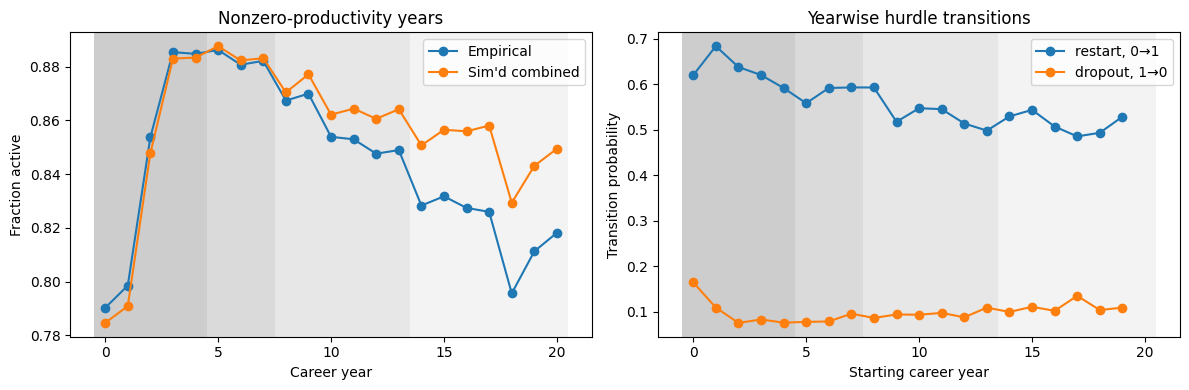

In [15]:
# Cell 10: binary path dx

emp_state_by_year = (
    df[df[age_col].between(0, Y)]
    .groupby(age_col)["state"]
    .agg(n="size", frac_active="mean")
    .reset_index()
    .rename(columns={age_col: "year"}))

sim_state_by_year = pd.DataFrame({
    "year": np.arange(Y + 1),
    "frac_active": b_trajs_combined.mean(axis=1),
    "frac_zero": 1 - b_trajs_combined.mean(axis=1),})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_state_by_year["year"], emp_state_by_year["frac_active"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_state_by_year["year"], sim_state_by_year["frac_active"], marker="o", label="Sim'd combined", zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Fraction active")
axes[0].set_title("Nonzero-productivity years")
axes[0].legend()

axes[1].plot(year_transition_summary["year"], year_transition_summary["P_nothing_to_something"], marker="o", label="restart, 0→1", zorder = 3)
axes[1].plot(year_transition_summary["year"], year_transition_summary["P_something_to_nothing"], marker="o", label="dropout, 1→0", zorder = 3)
axes[1].set_xlabel("Starting career year")
axes[1].set_ylabel("Transition probability")
axes[1].set_title("Yearwise hurdle transitions")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_Dx.png", dpi=300, bbox_inches="tight")
plt.show()


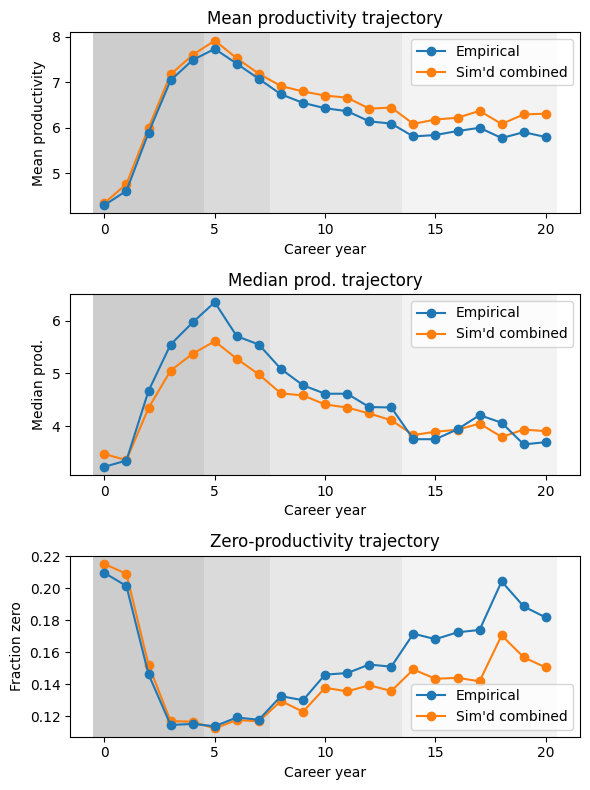

In [16]:
# Cell 11: canonical trajectory check

emp_mean = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .mean())

emp_median = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .median())

emp_frac_zero = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .apply(lambda x: (x == 0).mean()))

sim_mean = trajs_combined.mean(axis=1)
sim_median = np.median(trajs_combined, axis=1)
sim_frac_zero = (trajs_combined == 0).mean(axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label="Sim'd combined")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label="Sim'd combined")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

axes[2].plot(emp_frac_zero.index, emp_frac_zero.values, marker="o", label="Empirical", zorder = 3)
axes[2].plot(years, sim_frac_zero, marker="o", label="Sim'd combined")
axes[2].set_xlabel("Career year")
axes[2].set_ylabel("Fraction zero")
axes[2].set_title("Zero-productivity trajectory")
axes[2].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_trajectories.png", dpi=300, bbox_inches="tight")

plt.show()


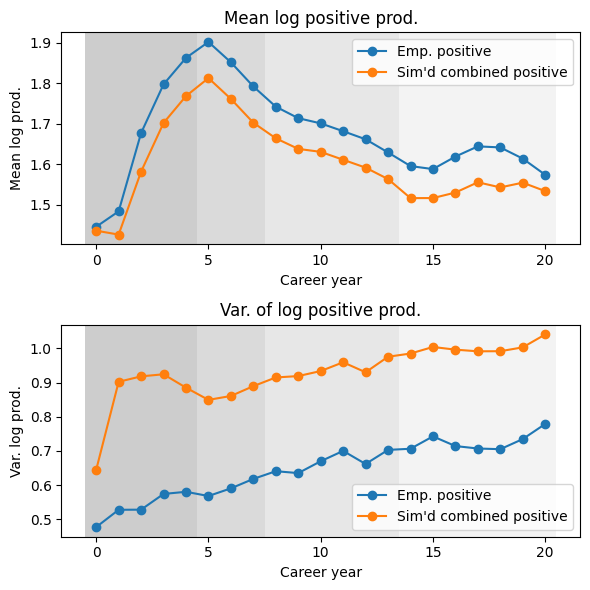

In [17]:
# Cell 12: yearwise log distrib dx

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_combined[t])

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
axes[0].plot(
    emp_year_stats["year"],
    emp_year_stats["mean_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[0].plot(
    sim_year_stats["year"],
    sim_year_stats["mean_log_prod_pos"],
    marker="o",
    label="Sim'd combined positive", zorder = 3
)
axes[0].set_title("Mean log positive prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(
    emp_year_stats["year"],
    emp_year_stats["var_log_prod_pos"],
    marker="o",
    label="Emp. positive", zorder = 3
)
axes[1].plot(
    sim_year_stats["year"],
    sim_year_stats["var_log_prod_pos"],
    marker="o",
    label="Sim'd combined positive", zorder = 3
)
axes[1].set_title("Var. of log positive prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_posLog.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
# Cell 13A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2


def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)


In [19]:
# Cell 13B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit, year_col="CareerAge", delta_col="log_delta", Y=Y)

TRJ = np.asarray(trajs_combined)
if TRJ.shape[0] != Y + 1 and TRJ.shape[1] == Y + 1:
    TRJ = TRJ.T

assert TRJ.shape[0] == Y + 1, f"Expected trajs_combined shape (Y+1, N), got {TRJ.shape}"

df_sim_delta = pd.DataFrame({
    "CareerAge": np.repeat(np.arange(Y), TRJ.shape[1]),
    "pubs_adj": TRJ[:-1, :].ravel(),
    "pubs_adj_next": TRJ[1:, :].ravel()})

df_sim_delta["log_delta"] = np.log(df_sim_delta["pubs_adj_next"] + EPS) - np.log(df_sim_delta["pubs_adj"] + EPS)

sim_delta_stats = make_log_delta_stats(df_sim_delta, year_col="CareerAge", delta_col="log_delta", Y=Y)


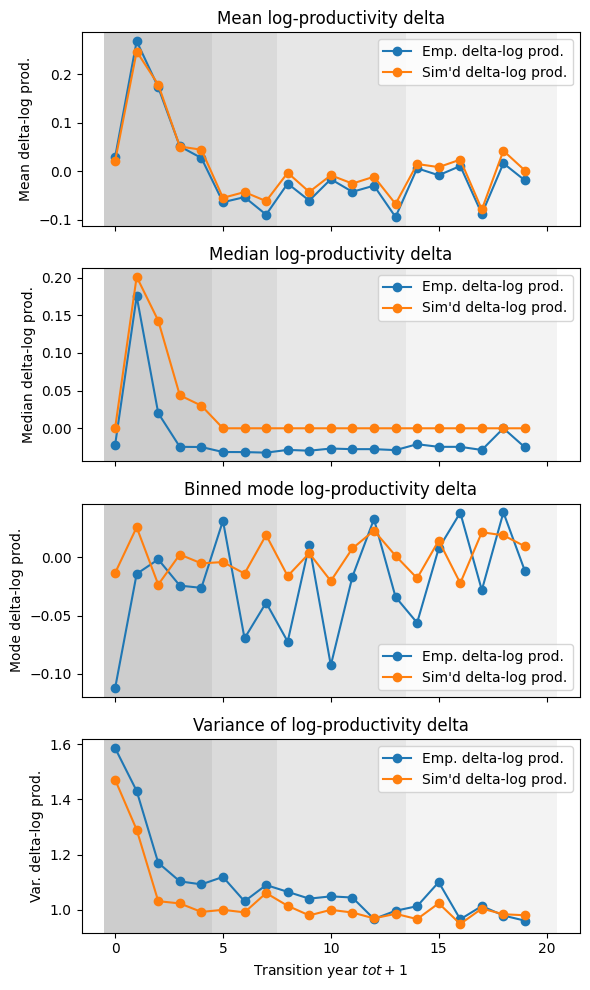

In [20]:
# Cell 13C: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5, end + 0.5, facecolor=shade, alpha=0.65, zorder=0)

axes[0].plot(emp_delta_stats["year"], emp_delta_stats["mean_log_delta"], marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"], sim_delta_stats["mean_log_delta"], marker="o", label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"], emp_delta_stats["median_log_delta"], marker="o", label="Emp. delta-log prod.", zorder=3)
axes[1].plot(sim_delta_stats["year"], sim_delta_stats["median_log_delta"], marker="o", label="Sim'd delta-log prod.", zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"], emp_delta_stats["mode_log_delta"], marker="o", label="Emp. delta-log prod.", zorder=3)
axes[2].plot(sim_delta_stats["year"], sim_delta_stats["mode_log_delta"], marker="o", label="Sim'd delta-log prod.", zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"], emp_delta_stats["var_log_delta"], marker="o", label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"], sim_delta_stats["var_log_delta"], marker="o", label="Sim'd delta-log prod.", zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png", dpi=300, bbox_inches="tight")
plt.show()


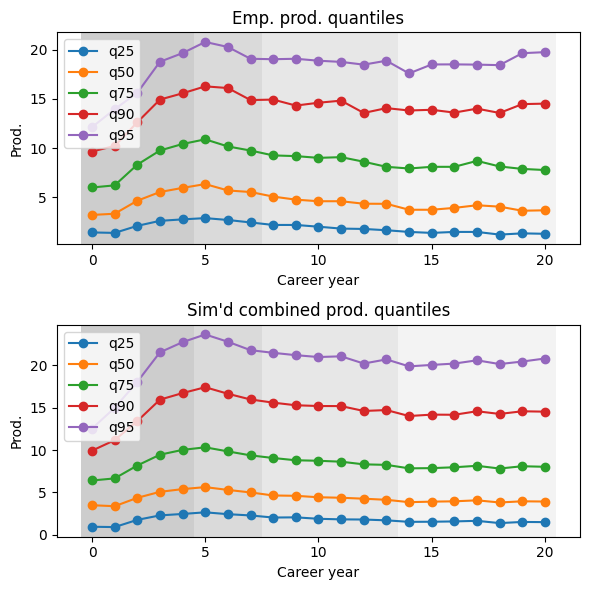

In [21]:
# Cell 14: yearwise quantile distrib dx

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
for qcol in qcols:
    axes[0].plot(
        emp_year_stats["year"],
        emp_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(
        sim_year_stats["year"],
        sim_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[1].set_title("Sim'd combined prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()


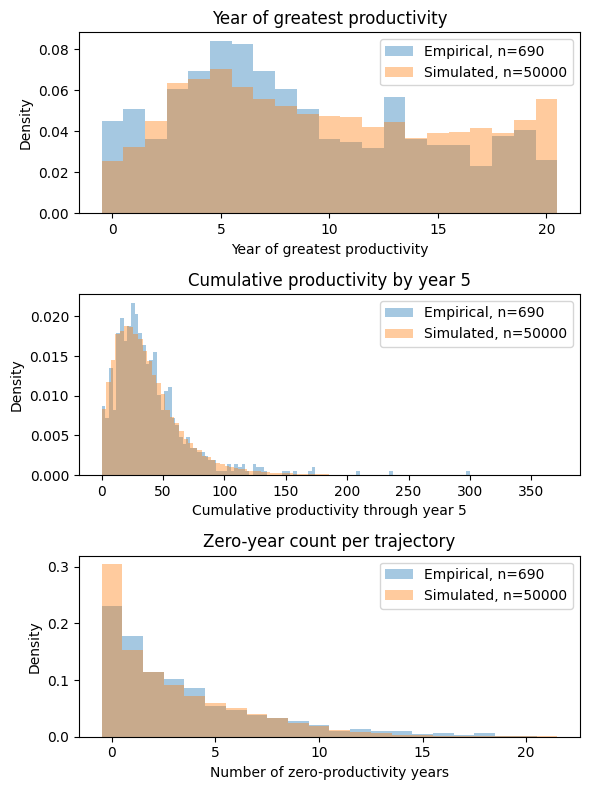

Full empirical trajectories: 690
Simulated trajectories: 50000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.0889049275362318), pvalue=np.float64(3.9190065922392534e-05), statistic_location=np.int64(9), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.03758840579710146), pvalue=np.float64(0.28390399029342617), statistic_location=np.float64(15.994757986277762), statistic_sign=np.int8(-1))
KS zero-year count: KstestResult(statistic=np.float64(0.07406521739130434), pvalue=np.float64(0.0010760478028855399), statistic_location=np.int64(0), statistic_sign=np.int8(-1))


In [22]:
# Cell 15: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)
emp_zero_count = (emp_panel_full == 0).sum(axis=1)

sim_year_max = np.argmax(trajs_combined, axis=0)
sim_cum_y5 = trajs_combined[0:6, :].sum(axis=0)
sim_zero_count = (trajs_combined == 0).sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)
ks_zero_count = stats.ks_2samp(emp_zero_count, sim_zero_count)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))

axes[0].hist(
    emp_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(
    sim_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(
    emp_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(
    sim_cum_y5,
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

axes[2].hist(
    emp_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_zero_count)}")

axes[2].hist(
    sim_zero_count,
    bins=np.arange(-0.5, Y + 2.5, 1),
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_zero_count)}")

axes[2].set_xlabel("Number of zero-productivity years")
axes[2].set_ylabel("Density")
axes[2].set_title("Zero-year count per trajectory")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_distribs.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_combined.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)
print("KS zero-year count:", ks_zero_count)


In [23]:
# Cell 18: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "empirical_frac_zero_y0": emp_frac_zero.loc[0],
    "empirical_frac_zero_y5": emp_frac_zero.loc[5],
    "empirical_frac_zero_y10": emp_frac_zero.loc[10],
    "empirical_frac_zero_y20": emp_frac_zero.loc[20],
    "simulated_frac_zero_y0": sim_frac_zero[0],
    "simulated_frac_zero_y5": sim_frac_zero[5],
    "simulated_frac_zero_y10": sim_frac_zero[10],
    "simulated_frac_zero_y20": sim_frac_zero[20],
    "scholar_effect_tau_mom": tau_scholar,
    "scholar_effect_sd_empirical_shrunk": scholar_effect_sd_empirical,
    "positive_ar1_effect_scale": POSITIVE_AR1_EFFECT_SCALE,
    "hurdle_effect_scale": HURDLE_EFFECT_SCALE,
    "init_active_effect_scale": INIT_ACTIVE_EFFECT_SCALE,
    "init_magnitude_effect_scale": INIT_MAGNITUDE_EFFECT_SCALE,
    "restart_magnitude_effect_scale": RESTART_MAGNITUDE_EFFECT_SCALE,
    "init_active_scholar_coef": fitted_init_active_scholar_coef,
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_delta_log1p_active_run_excess": fitted_active_duration_delta,
    "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
    "dropout_nll": opt.fun,
    "restart_rho_zero_run_excess": fitted_restart_rho,
    "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
    "restart_duration_nll": restart_opt.fun,
    "p_init_active": p_init_active,
    "gamma_q0_shape": gamma_q0_shape,
    "gamma_q0_scale": gamma_q0_scale,
    "gamma_q0_rate": gamma_q0_rate,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "simulated_y20_q95": np.quantile(trajs_combined[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_combined[20], 0.99),
    "simulated_y20_max": np.max(trajs_combined[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
    "ks_zero_count_stat": ks_zero_count.statistic,
    "ks_zero_count_p": ks_zero_count.pvalue,
}

summary_df = pd.DataFrame([summary])

print("Yearwise unconditioned transition summary, retained for comparison")
display(year_transition_summary.round(3))

print("Scholar effect summary")
display(scholar_effect_summary.round(4))

print("Parametric productivity + active-duration + scholar-effect dropout model summary")
display(dropout_param_summary.round(4))

print("Parametric zero-run-duration + scholar-effect restart model summary")
display(restart_param_summary.round(4))


print("Yearwise positive-only AR(1) params")
display(year_ar1_params)

print("Gamma initial / exponential restart params")
display(pd.DataFrame([{
    "gamma_q0_shape": gamma_q0_shape,
    "gamma_q0_scale": gamma_q0_scale,
    "gamma_q0_rate": gamma_q0_rate,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "p_init_active": p_init_active,
    "tau_scholar": tau_scholar,
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_delta_log1p_active_run_excess": fitted_active_duration_delta,
    "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
    "restart_rho_zero_run_excess": fitted_restart_rho,
    "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
    "init_active_scholar_coef": fitted_init_active_scholar_coef,
}]))

print("Summary")
display(summary_df)


Yearwise unconditioned transition summary, retained for comparison


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


Scholar effect summary


,n_scholars_with_positive_years,sigma_within2_centered_log_q,raw_var_scholar_mean_centered_log_q,mean_noise_var,tau_scholar2_mom,tau_scholar_mom,sd_shrunk_scholar_effect,mean_shrinkage,median_shrinkage
0,2425,0.3139,0.3516,0.0352,0.3164,0.5625,0.5235,0.9084,0.9291


Parametric productivity + active-duration + scholar-effect dropout model summary


...

,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


Gamma initial / exponential restart params


,gamma_q0_shape,gamma_q0_scale,gamma_q0_rate,alpha_restart,lambda_restart,restart_n,p_init_active,tau_scholar,dropout_gamma_log1p_q,dropout_delta_log1p_active_run_excess,dropout_scholar_coef_per_tau,restart_rho_zero_run_excess,restart_scholar_coef_per_tau,init_active_scholar_coef
0,2.15167,2.531674,0.394996,4.299784,0.23257,3061,0.790237,0.562505,0.4315,-0.931085,-0.472692,0.290854,0.237238,0.913469


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,restart_n,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p,ks_zero_count_stat,ks_zero_count_p
0,4.304679,7.729319,6.428626,5.797863,4.346794,7.911635,6.707016,6.309463,3.225469,6.352937,...,3061,20.825136,40.070862,174.49619,0.088905,0.000039,0.037588,0.283904,0.074065,0.001076


In [24]:
# Cell 19: save outputs

year_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_yearTransitionSummary.csv", index=False)
stage_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageTransitionSummary.csv", index=False)
scholar_effect_summary.to_csv(RESULTS / f"{MODEL_TAG}_scholarEffectSummary.csv", index=False)
scholar_effect_df.to_csv(RESULTS / f"{MODEL_TAG}_scholarEffects_empiricalEstimated.csv", index=False)
dropout_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramDropoutSummary.csv", index=False)
restart_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramRestartDurationSummary.csv", index=False)
year_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_posYearLog.csv", index=False)
global_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_pos_globalLog.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv", index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)


def matrix_dict_to_frame(matrix_dict, level_name):
    rows = []
    for key, mat in matrix_dict.items():
        rows.append({
            level_name: key,
            "P_nothing_to_nothing": mat.loc[0, 0],
            "P_nothing_to_something": mat.loc[0, 1],
            "P_something_to_nothing": mat.loc[1, 0],
            "P_something_to_something": mat.loc[1, 1],
        })
    return pd.DataFrame(rows)


matrix_dict_to_frame(year_P, "year").to_csv(RESULTS / f"{MODEL_TAG}_yearPMatrices_comparison.csv", index=False)
matrix_dict_to_frame(stage_P, "stage").to_csv(RESULTS / f"{MODEL_TAG}_stagePMatrices_comparison.csv", index=False)

pd.DataFrame({
    "year": np.arange(Y),
    "dropout_intercept": fitted_intercepts,
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_delta_log1p_active_run_excess": fitted_active_duration_delta,
    "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
    "pred_drop_q50_active_run1_u_low": [predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=-tau_scholar) for year in range(Y)],
    "pred_drop_q50_active_run1_u_mid": [predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=0.0) for year in range(Y)],
    "pred_drop_q50_active_run1_u_high": [predict_dropout_prob(q_ref[0.50], year, active_run_length=1, scholar_effect=tau_scholar) for year in range(Y)],
    "pred_drop_q50_active_run2": [predict_dropout_prob(q_ref[0.50], year, active_run_length=2, scholar_effect=0.0) for year in range(Y)],
    "pred_drop_q50_active_run5": [predict_dropout_prob(q_ref[0.50], year, active_run_length=5, scholar_effect=0.0) for year in range(Y)],
    "pred_drop_q50_active_run10": [predict_dropout_prob(q_ref[0.50], year, active_run_length=10, scholar_effect=0.0) for year in range(Y)],
    "restart_intercept": fitted_restart_intercepts,
    "restart_rho_zero_run_excess": fitted_restart_rho,
    "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
    "pred_restart_run1_u_low": [predict_restart_prob(1, year, scholar_effect=-tau_scholar) for year in range(Y)],
    "pred_restart_run1_u_mid": [predict_restart_prob(1, year, scholar_effect=0.0) for year in range(Y)],
    "pred_restart_run1_u_high": [predict_restart_prob(1, year, scholar_effect=tau_scholar) for year in range(Y)],
    "pred_restart_run2_u_mid": [predict_restart_prob(2, year, scholar_effect=0.0) for year in range(Y)],
    "pred_restart_run3_u_mid": [predict_restart_prob(3, year, scholar_effect=0.0) for year in range(Y)],
    "pred_restart_run5_u_mid": [predict_restart_prob(5, year, scholar_effect=0.0) for year in range(Y)],
}).to_csv(RESULTS / f"{MODEL_TAG}_paramHurdleParams.csv", index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("parametric productivity-, active-duration-, zero-run-, and scholar-effect-conditioned hurdle with gamma initialization and yearwise AR(1) report\n")
    f.write("\n")
    f.write("Model\n")
    f.write("\n")
    f.write("u_i is a latent scholar effect drawn from an estimated population distribution, not fit to named simulated scholars.\n")
    f.write("B_0 ~ Bernoulli(logistic(eta_0 + phi_0 u_i)).\n")
    f.write("Q_0 ~ Gamma(k_0, theta_0) * exp(s_0 u_i) / E[exp(s_0 u_i)] if B_0=1; otherwise Q_0=0.\n")
    f.write("If B_t=0, Pr(B_{t+1}=1 | L_t, u_i) = logistic(c_t - rho (L_t - 1) + phi_R u_i/tau), where L_t is current zero-run length.\n")
    f.write("If B_t=1, Pr(B_{t+1}=0 | Q_t, A_t, u_i) = logistic(a_t - gamma log(1 + Q_t) + delta log(1 + A_t - 1) + phi_D u_i/tau), where A_t is current active-run length.\n")
    f.write("Q_{t+1} = 0 if B_{t+1}=0.\n")
    f.write("Q_{t+1} ~ Exponential(lambda_R) * exp(s_R u_i) / E[exp(s_R u_i)] if B_t=0 and B_{t+1}=1.\n")
    f.write("log(Q_{t+1}) = intercept_t + beta_t log(Q_t) + s_Z u_i + error_t if B_t=1 and B_{t+1}=1.\n")
    f.write("error_t ~ Normal(0, sigma_t^2).\n")
    f.write("\n")
    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n")
    f.write(f"SCHOLAR_EFFECT_DRAW_MODE = {SCHOLAR_EFFECT_DRAW_MODE}\n")
    f.write(f"POSITIVE_AR1_EFFECT_SCALE = {POSITIVE_AR1_EFFECT_SCALE}\n")
    f.write(f"HURDLE_EFFECT_SCALE = {HURDLE_EFFECT_SCALE}\n")
    f.write(f"INIT_ACTIVE_EFFECT_SCALE = {INIT_ACTIVE_EFFECT_SCALE}\n")
    f.write(f"INIT_MAGNITUDE_EFFECT_SCALE = {INIT_MAGNITUDE_EFFECT_SCALE}\n")
    f.write(f"RESTART_MAGNITUDE_EFFECT_SCALE = {RESTART_MAGNITUDE_EFFECT_SCALE}\n")
    f.write(f"tau_scholar = {tau_scholar}\n")
    f.write(f"scholar_effect_sd_empirical = {scholar_effect_sd_empirical}\n")
    f.write(f"p_init_active = {p_init_active}\n")
    f.write(f"fitted_init_active_intercept = {fitted_init_active_intercept}\n")
    f.write(f"fitted_init_active_scholar_coef = {fitted_init_active_scholar_coef}\n")
    f.write(f"gamma_q0_shape = {gamma_q0_shape}\n")
    f.write(f"gamma_q0_scale = {gamma_q0_scale}\n")
    f.write(f"gamma_q0_rate = {gamma_q0_rate}\n")
    f.write(f"alpha_restart = {alpha_restart}\n")
    f.write(f"lambda_restart = {lambda_restart}\n")
    f.write(f"dropout_gamma_log1p_q = {fitted_gamma}\n")
    f.write(f"dropout_delta_log1p_active_run_excess = {fitted_active_duration_delta}\n")
    f.write(f"dropout_scholar_coef_per_tau = {fitted_dropout_scholar_coef}\n")
    f.write(f"dropout_nll = {opt.fun}\n")
    f.write(f"restart_rho_zero_run_excess = {fitted_restart_rho}\n")
    f.write(f"restart_scholar_coef_per_tau = {fitted_restart_scholar_coef}\n")
    f.write(f"restart_duration_nll = {restart_opt.fun}\n")
    f.write("Scholar effect summary\n")
    f.write("\n")
    f.write(scholar_effect_summary.to_string(index=False))
    f.write("\n\nParametric productivity + active-duration + scholar-effect dropout summary\n")
    f.write("\n")
    f.write(dropout_param_summary.to_string(index=False))
    f.write("\n\nParametric restart-duration + scholar-effect summary\n")
    f.write("\n")
    f.write(restart_param_summary.to_string(index=False))
    f.write("\n\nYearwise binary transition summary\n")
    f.write("\n")
    f.write(year_transition_summary.to_string(index=False))
    f.write("\n\nYearwise positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(year_ar1_params.to_string(index=False))
    f.write("\n\nGlobal positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(global_ar1_params.to_string(index=False))
    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))


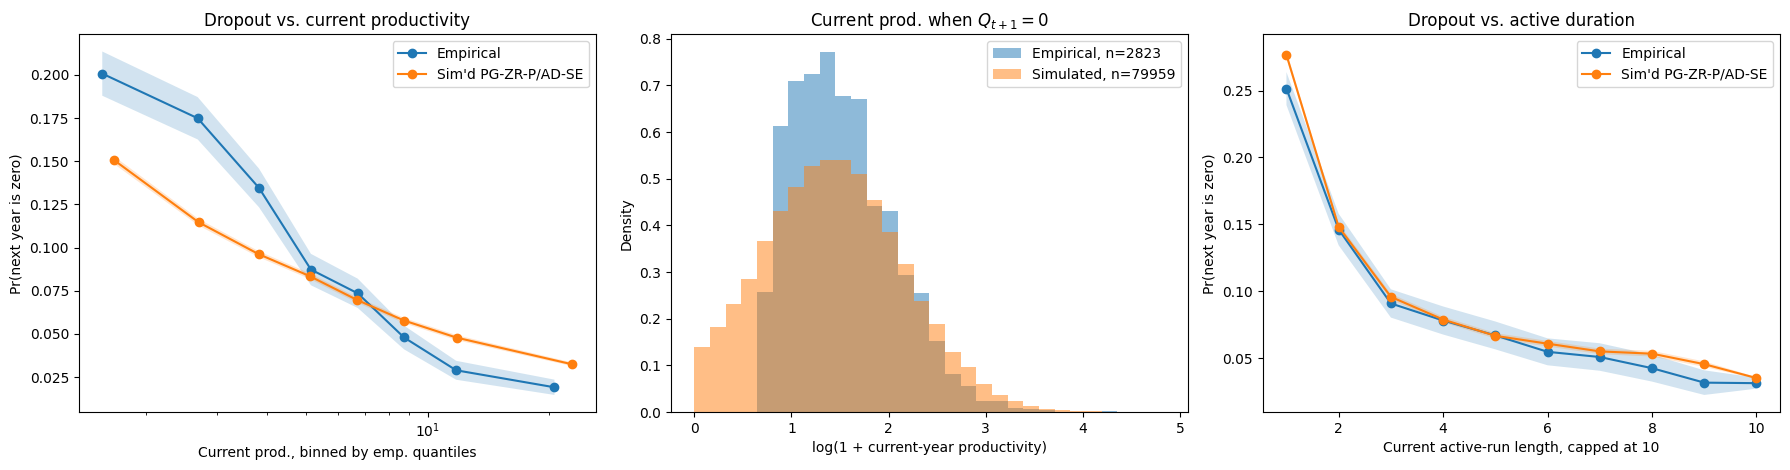

Empirical dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",3760,0.200798,1.558408,1.502068,Empirical,1.558408,0.006533,0.187993,0.213603
1,"(2.181, 3.229]",3687,0.174939,2.687266,2.644809,Empirical,2.687266,0.006257,0.162676,0.187202
2,"(3.229, 4.419]",3575,0.134545,3.815607,3.811037,Empirical,3.815607,0.005707,0.123359,0.145731
3,"(4.419, 5.829]",3700,0.087297,5.131218,5.084822,Empirical,5.131218,0.004640,0.078202,0.096393
4,"(5.829, 7.622]",3631,0.073533,6.704440,6.691238,Empirical,6.704440,0.004332,0.065044,0.082023
5,"(7.622, 10.037]",3711,0.047966,8.732543,8.706188,Empirical,8.732543,0.003508,0.041090,0.054841
6,"(10.037, 14.001]",3592,0.028953,11.763405,11.657458,Empirical,11.763405,0.002798,0.023470,0.034437
7,"(14.001, 80.687]",3666,0.019094,20.622869,18.392702,Empirical,20.622869,0.002260,0.014664,0.023525


Simulated dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",99709,0.150849,1.663115,1.675130,Simulated,1.663115,0.001133,0.148627,0.153071
1,"(2.181, 3.229]",106485,0.114711,2.700791,2.697380,Simulated,2.700791,0.000977,0.112797,0.116625
2,"(3.229, 4.419]",109444,0.096204,3.807993,3.798261,Simulated,3.807993,0.000891,0.094457,0.097951
3,"(4.419, 5.829]",105756,0.083522,5.093586,5.081053,Simulated,5.093586,0.000851,0.081855,0.085190
4,"(5.829, 7.622]",100404,0.069698,6.678175,6.654426,Simulated,6.678175,0.000804,0.068123,0.071274
5,"(7.622, 10.037]",91788,0.057742,8.739523,8.693556,Simulated,8.739523,0.000770,0.056233,0.059251
6,"(10.037, 14.001]",84910,0.047862,11.797164,11.690214,Simulated,11.797164,0.000733,0.046427,0.049298
7,"(14.001, 80.687]",109215,0.032395,22.837260,19.447040,Simulated,22.837260,0.000536,0.031345,0.033445


Empirical dropout by active-run duration:


,active_duration_bin,n,dropout_rate,mean_q_t,median_q_t,source,se,lower,upper
0,1,4764,0.251469,4.896393,3.607450,Empirical,0.006286,0.239149,0.263790
1,2,3429,0.146107,5.597746,4.295880,Empirical,0.006032,0.134284,0.157929
2,3,2840,0.090845,6.768667,5.451813,Empirical,0.005393,0.080275,0.101415
3,4,2510,0.078088,7.821376,6.130901,Empirical,0.005355,0.067591,0.088584
4,5,2211,0.066938,8.368717,6.782928,Empirical,0.005315,0.056521,0.077355
5,6,1957,0.054676,8.695126,7.012981,Empirical,0.005139,0.044603,0.064748
6,7,1752,0.050799,8.725501,7.214900,Empirical,0.005246,0.040517,0.061082
7,8,1555,0.042444,8.777408,7.235878,Empirical,0.005112,0.032423,0.052464
8,9,1391,0.031632,8.756332,7.162507,Empirical,0.004693,0.022434,0.040830
9,10,6913,0.031245,9.401184,7.510338,Empirical,0.002093,0.027144,0.035347


Simulated dropout by active-run duration:


,active_duration_bin,n,dropout_rate,mean_q_t,median_q_t,source,se,lower,upper
0,1,118198,0.276646,4.452934,3.305252,Simulated,0.001301,0.274096,0.279196
1,2,82878,0.148061,5.781328,4.128034,Simulated,0.001234,0.145643,0.150479
2,3,68989,0.095769,7.098722,5.124648,Simulated,0.001120,0.093573,0.097965
3,4,61071,0.078794,8.198485,5.853454,Simulated,0.001090,0.076657,0.080930
4,5,54989,0.066632,8.700651,6.205529,Simulated,0.001063,0.064547,0.068716
5,6,50220,0.060753,9.015362,6.407814,Simulated,0.001066,0.058663,0.062842
6,7,46199,0.055001,8.818162,6.264813,Simulated,0.001061,0.052922,0.057080
7,8,42784,0.053291,8.593834,6.069090,Simulated,0.001086,0.051163,0.055419
8,9,39613,0.045440,8.501752,5.967845,Simulated,0.001046,0.043389,0.047491
9,10,291844,0.035067,8.377356,5.650625,Simulated,0.000341,0.034399,0.035734


In [25]:
# conditioned dropout

emp_dx = trans.loc[
    (trans["state"] == 1) &
    trans["pubs_adj"].notna() &
    trans["pubs_adj_next"].notna() &
    trans["active_run_length"].notna(),
    ["CareerAge", "pubs_adj", "pubs_adj_next", "active_run_length"]
].copy()

emp_dx["drops_to_zero"] = (emp_dx["pubs_adj_next"] == 0).astype(int)

sim_dx = pd.DataFrame({
    "CareerAge": np.repeat(np.arange(Y), trajs_combined.shape[1]),
    "pubs_adj": trajs_combined[:-1, :].ravel(),
    "pubs_adj_next": trajs_combined[1:, :].ravel(),
    "active_run_length": active_run_trajs_combined[:-1, :].ravel(),
})

sim_dx = sim_dx.loc[sim_dx["pubs_adj"] > 0].copy()
sim_dx["drops_to_zero"] = (sim_dx["pubs_adj_next"] == 0).astype(int)

n_bins = 8

bin_edges = np.quantile(emp_dx["pubs_adj"], np.linspace(0, 1, n_bins + 1))
bin_edges = np.unique(bin_edges)

if len(bin_edges) < 3:
    raise ValueError("Not enough unique emp bin edges")

emp_dx["prod_bin"] = pd.cut(
    emp_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)

sim_dx["prod_bin"] = pd.cut(
    sim_dx["pubs_adj"],
    bins=bin_edges,
    include_lowest=True,
    duplicates="drop"
)


def summarize_dropout_by_bin(df, label):
    out = (
        df.groupby("prod_bin", observed=False)
        .agg(
            n=("drops_to_zero", "size"),
            dropout_rate=("drops_to_zero", "mean"),
            mean_q_t=("pubs_adj", "mean"),
            median_q_t=("pubs_adj", "median")
        )
        .reset_index()
    )

    out["source"] = label
    out["bin_mid"] = out["mean_q_t"]

    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)

    return out


def summarize_dropout_by_active_duration(df, label, max_run=10):
    d = df.copy()
    d["active_duration_bin"] = np.minimum(d["active_run_length"].clip(lower=1).astype(int), max_run)
    out = (
        d.groupby("active_duration_bin")
        .agg(
            n=("drops_to_zero", "size"),
            dropout_rate=("drops_to_zero", "mean"),
            mean_q_t=("pubs_adj", "mean"),
            median_q_t=("pubs_adj", "median"),
        )
        .reset_index()
    )
    out["source"] = label
    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)
    return out


emp_bin_summary = summarize_dropout_by_bin(emp_dx, "Empirical")
sim_bin_summary = summarize_dropout_by_bin(sim_dx, "Simulated")
dropout_bin_summary = pd.concat([emp_bin_summary, sim_bin_summary], ignore_index=True)

emp_active_duration_summary = summarize_dropout_by_active_duration(emp_dx, "Empirical")
sim_active_duration_summary = summarize_dropout_by_active_duration(sim_dx, "Simulated")
dropout_active_duration_summary = pd.concat([emp_active_duration_summary, sim_active_duration_summary], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["dropout_rate"],
    marker="o",
    label="Empirical"
)

axes[0].fill_between(
    emp_bin_summary["bin_mid"],
    emp_bin_summary["lower"],
    emp_bin_summary["upper"],
    alpha=0.20
)

axes[0].plot(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["dropout_rate"],
    marker="o",
    label="Sim'd PG-ZR-P/AD-SE"
)

axes[0].fill_between(
    sim_bin_summary["bin_mid"],
    sim_bin_summary["lower"],
    sim_bin_summary["upper"],
    alpha=0.20
)

axes[0].set_xlabel("Current prod., binned by emp. quantiles")
axes[0].set_ylabel("Pr(next year is zero)")
axes[0].set_title("Dropout vs. current productivity")
axes[0].legend()
axes[0].set_xscale("log")

emp_prezero = emp_dx.loc[emp_dx["drops_to_zero"] == 1, "pubs_adj"]
sim_prezero = sim_dx.loc[sim_dx["drops_to_zero"] == 1, "pubs_adj"]

hist_bins = np.histogram_bin_edges(
    np.log1p(pd.concat([emp_prezero, sim_prezero])),
    bins=30
)

axes[1].hist(
    np.log1p(emp_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"Empirical, n={len(emp_prezero)}"
)

axes[1].hist(
    np.log1p(sim_prezero),
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label=f"Simulated, n={len(sim_prezero)}"
)

axes[1].set_xlabel("log(1 + current-year productivity)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Current prod. when $Q_{t+1}=0$")
axes[1].legend()

axes[2].plot(
    emp_active_duration_summary["active_duration_bin"],
    emp_active_duration_summary["dropout_rate"],
    marker="o",
    label="Empirical"
)
axes[2].fill_between(
    emp_active_duration_summary["active_duration_bin"],
    emp_active_duration_summary["lower"],
    emp_active_duration_summary["upper"],
    alpha=0.20
)
axes[2].plot(
    sim_active_duration_summary["active_duration_bin"],
    sim_active_duration_summary["dropout_rate"],
    marker="o",
    label="Sim'd PG-ZR-P/AD-SE"
)
axes[2].fill_between(
    sim_active_duration_summary["active_duration_bin"],
    sim_active_duration_summary["lower"],
    sim_active_duration_summary["upper"],
    alpha=0.20
)
axes[2].set_xlabel("Current active-run length, capped at 10")
axes[2].set_ylabel("Pr(next year is zero)")
axes[2].set_title("Dropout vs. active duration")
axes[2].legend()

plt.tight_layout()
plt.show()

fig.savefig(
    FIGURES / f"{MODEL_TAG}_paramCondProdActiveDropout.png",
    dpi=300,
    bbox_inches="tight"
)

dropout_bin_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_paramCondProdDropoutSummary.csv",
    index=False
)

dropout_active_duration_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_paramCondActiveDurationDropoutSummary.csv",
    index=False
)

print("Empirical dropout by current productivity bin:")
display(emp_bin_summary)

print("Simulated dropout by current productivity bin:")
display(sim_bin_summary)

print("Empirical dropout by active-run duration:")
display(emp_active_duration_summary)

print("Simulated dropout by active-run duration:")
display(sim_active_duration_summary)


In [26]:
# save trajectory array

OUT = TRAJECTORIES
OUT.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "hurdle_ar1_pg_zr_pad_se"
TRJ = trajs_combined

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_NAME}_trajs.npy"
np.save(save_path, TRJ)
print(f"Saved {MODEL_NAME} trajectories to: {save_path}")

u_save_path = OUT / f"{MODEL_NAME}_scholar_effects.npy"
np.save(u_save_path, np.asarray(scholar_effects_simulated))
print(f"Saved {MODEL_NAME} scholar effects to: {u_save_path}")
print(f"Saved trajectories to: {save_path}")


Saved hurdle_ar1_pg_zr_pad_se trajectories to: /Users/samlunemagid/Desktop/shockley_repo/data/trajectory_correlation_data/hurdle_ar1_pg_zr_pad_se_trajs.npy
Saved hurdle_ar1_pg_zr_pad_se scholar effects to: /Users/samlunemagid/Desktop/shockley_repo/data/trajectory_correlation_data/hurdle_ar1_pg_zr_pad_se_scholar_effects.npy
Saved trajectories to: /Users/samlunemagid/Desktop/shockley_repo/data/trajectory_correlation_data/hurdle_ar1_pg_zr_pad_se_trajs.npy
